Upload The **Json FIle** FIrst

In [ ]:
from google.colab import files
files.upload()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!pip install kaggle

In [7]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:01<00:00, 83.5MB/s]



In [8]:
!unzip cifake-real-and-ai-generated-synthetic-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/REAL/4500 (10).jpg  
  inflating: train/REAL/4500 (2).jpg  
  inflating: train/REAL/4500 (3).jpg  
  inflating: train/REAL/4500 (4).jpg  
  inflating: train/REAL/4500 (5).jpg  
  inflating: train/REAL/4500 (6).jpg  
  inflating: train/REAL/4500 (7).jpg  
  inflating: train/REAL/4500 (8).jpg  
  inflating: train/REAL/4500 (9).jpg  
  inflating: train/REAL/4500.jpg     
  inflating: train/REAL/4501 (10).jpg  
  inflating: train/REAL/4501 (2).jpg  
  inflating: train/REAL/4501 (3).jpg  
  inflating: train/REAL/4501 (4).jpg  
  inflating: train/REAL/4501 (5).jpg  
  inflating: train/REAL/4501 (6).jpg  
  inflating: train/REAL/4501 (7).jpg  
  inflating: train/REAL/4501 (8).jpg  
  inflating: train/REAL/4501 (9).jpg  
  inflating: train/REAL/4501.jpg     
  inflating: train/REAL/4502 (10).jpg  
  inflating: train/REAL/4502 (2).jpg  
  inflating: train/REAL/4502 (3).jpg  
  inflating: train/REAL/4502 (4).jpg  
  inflating:

In [9]:
!ls
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

cifake-real-and-ai-generated-synthetic-images.zip  sample_data	train
drive						   test


In [10]:
!ls train
!ls test

FAKE  REAL
FAKE  REAL


In [11]:
import tensorflow

In [12]:


from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data preprocessing
train_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Load the training data
train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(128, 128),  # Resize images to 128x128
    batch_size=32,
    class_mode='binary'      # Binary classification: real or fake
)

# Load the test data
test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [13]:
print(train_generator.class_indices)
print(test_generator.class_indices)

{'FAKE': 0, 'REAL': 1}
{'FAKE': 0, 'REAL': 1}


In [14]:
train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(128, 128),
    batch_size=16,  # Smaller batch size
    class_mode='binary'
)


Found 100000 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20
)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 83s 13ms/step - accuracy: 0.8562 - loss: 0.3393 - val_accuracy: 0.9072 - val_loss: 0.2363
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 79s 13ms/step - accuracy: 0.9065 - loss: 0.2392 - val_accuracy: 0.9117 - val_loss: 0.2171
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 80s 13ms/step - accuracy: 0.9218 - loss: 0.2028 - val_accuracy: 0.9265 - val_loss: 0.1888
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 79s 13ms/step - accuracy: 0.9311 - loss: 0.1789 - val_accuracy: 0.9265 - val_loss: 0.1919
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 79s 13ms/step - accuracy: 0.9400 - loss: 0.1585 - val_accuracy: 0.9316 - val_loss: 0.1838
Epoch 6/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 80s 13ms/step - accuracy: 0.9462 - loss: 0.1396 - val_accuracy: 0.9274 - val_loss: 0.2045
Epoch 7/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 79s 13ms/step - accuracy: 0.9527 - loss: 0.1247 - val_accuracy: 0.9299 - val_loss: 0.2143
Epoch 8/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 80s 13ms/step - accuracy: 0.9561 - loss: 0.11

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

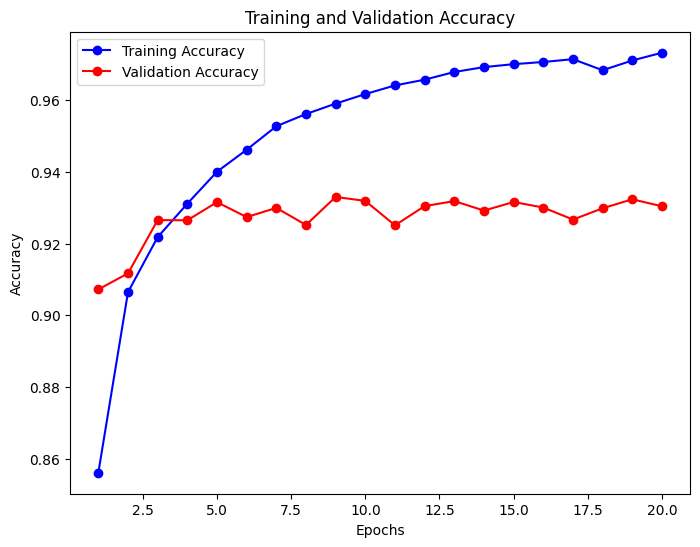

In [27]:
def plot_accuracy(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    epochs = range(1, len(acc) + 1)

    # Plot accuracy
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(history)

625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step


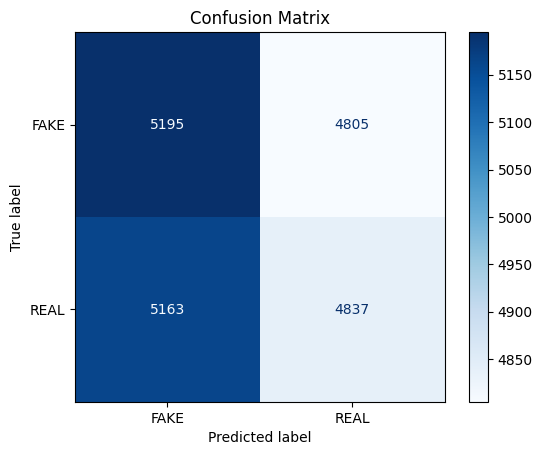

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(model, test_generator):

    # Get true labels and predictions
    test_generator.reset()
    y_true = test_generator.classes
    y_pred = model.predict(test_generator)
    y_pred_classes = (y_pred > 0.5).astype(int)  # Convert probabilities to binary class labels

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    class_labels = list(test_generator.class_indices.keys())

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, test_generator)

In [29]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9304 - loss: 0.4041
Test Accuracy: 93.04%


/tmp/ipykernel_3681/159958058.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


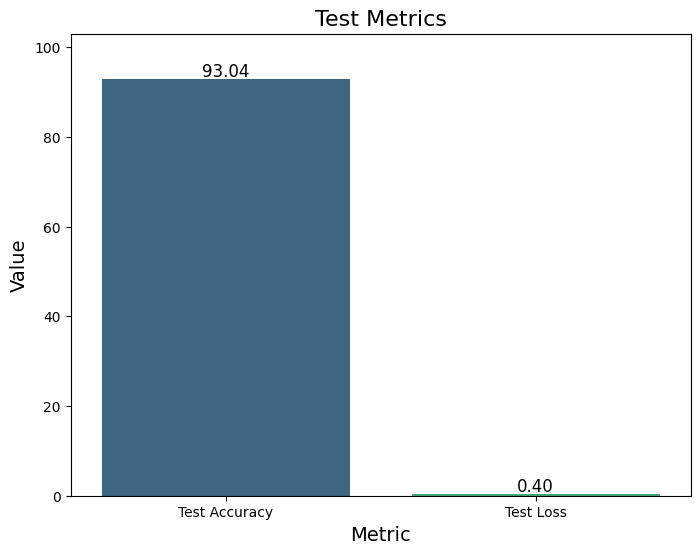

In [30]:
def plot_test_metrics(test_loss, test_accuracy):

    # Data for plotting
    metrics = ['Test Accuracy', 'Test Loss']
    values = [test_accuracy * 100, test_loss]

    # Create a bar plot
    plt.figure(figsize=(8, 6))
    sns.barplot(x=metrics, y=values, palette='viridis')

    # Annotate the bars with the values
    for i, v in enumerate(values):
        plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontsize=12)

    # Customize plot
    plt.title('Test Metrics', fontsize=16)
    plt.ylabel('Value', fontsize=14)
    plt.xlabel('Metric', fontsize=14)
    plt.ylim(0, max(values) + 10)
    plt.show()
plot_test_metrics(test_loss, test_accuracy)

In [31]:
model.save('cifake_model.keras')

In [36]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

model = load_model('/content/cifake_model.keras')

def predict_image(image_path):

    img = load_img(image_path, target_size=(128, 128))  # Resize to match model input
    img_array = img_to_array(img) / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    prediction = model.predict(img_array)
    return "Real" if prediction[0][0] > 0.5 else "AI-Generated"

image_path = "/content/train/REAL/0008.jpg"
result = predict_image(image_path)
print(f"The image is predicted to be: {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
The image is predicted to be: Real
